# Imbalanced classes

### Resampling, class weights, and the threshold almost nobody moves

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why accuracy is unusable on a rare class, how to write random undersampling, random oversampling and SMOTE yourself in NumPy, what `class_weight="balanced"` actually does, why moving the decision threshold usually does the same job for a tenth of the work, and how much score you invent if you resample before splitting |
| **You should already know** | [Logistic regression](../01-logistic-regression/), [decision trees](../06-decision-trees/) |
| **Datasets** | UCI Dry Bean and UCI Breast Cancer, both cut down to a rare positive class |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [03-08 Multiclass and multilabel](../08-multiclass-and-multilabel/) |

---

## 1. The idea

One class is rare and it is the one you care about. Fraud, machine failure, a
disease that turns up in one patient out of a hundred. Every default in
scikit-learn assumes the two classes are roughly the same size, and when they
are not, three separate things go wrong.

**The metric goes first.** Accuracy on a problem with one percent positives is
almost entirely a measurement of how well you predict the other ninety-nine
percent, which takes no skill at all.

**The fit goes second, mildly.** A model that minimises average loss spends its
capacity where the rows are. The rare class barely moves the total, so the
boundary drifts away from it.

**The decision goes third, badly.** Calling a row positive when its probability
clears 0.5 only makes sense if the classes are balanced and a false alarm costs
the same as a miss. Neither is true here, and 0.5 is a default nobody chose.

Each of those has a standard fix. Change the metric. Change the data by
resampling it, or change the loss by weighting it. Change the threshold.

The argument I want to make is that the last one is underrated. Moving the
threshold is one line of code, it costs no extra fitting, it cannot leak into
your test set, and it leaves you a dial you can turn until the recall matches
what the problem actually needs. Resampling gives you none of that, and as far
as I can measure here, it mostly does the same thing by a longer route.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Why accuracy fails here

I need an unbalanced problem, and I would rather build one from a dataset the
rest of the book already uses than download something new. Dry Bean has seven
varieties. I keep every DERMASON bean as the negative class and a small random
handful of SIRA beans as the positive class.

SIRA is a deliberate choice. BOMBAY beans are several times the size of
DERMASON and a single feature separates them, so a rare BOMBAY class would be
found by anything and every method in this notebook would tie at the top. SIRA
and DERMASON overlap heavily, which is the case where the fixes differ. I
measure that difference below rather than asking you to take my word for it.

In [2]:
X_all, y_all = datasets.dry_bean()
FEATURES = list(X_all.columns)

labels = y_all.astype(str).str.upper().to_numpy()
rare_rng = np.random.default_rng(SEED)


def unbalanced(rare_class, n_rare, majority="DERMASON", rng=rare_rng):
    """All of `majority`, plus `n_rare` rows of `rare_class` as the positives."""
    negatives = np.flatnonzero(labels == majority)
    pool = np.flatnonzero(labels == rare_class)
    positives = rng.choice(pool, size=n_rare, replace=False)
    keep = np.sort(np.concatenate([negatives, positives]))
    return (X_all.to_numpy(dtype=float)[keep], (labels[keep] == rare_class).astype(int))


X, y = unbalanced("SIRA", 60)
BASE_RATE = y.mean()

print(f"{len(y):,} rows, {X.shape[1]} features")
print(f"{int(y.sum())} positive, {int((1 - y).sum()):,} negative")
print(f"positive rate: {BASE_RATE:.2%}  (one positive per {1 / BASE_RATE:.0f} rows)")

3,606 rows, 16 features
60 positive, 3,546 negative
positive rate: 1.66%  (one positive per 60 rows)


The first number worth printing is the score of a model that does nothing at
all. Compare it against a plain logistic regression, cross-validated so the
comparison is honest, and read the metrics side by side.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             f1_score, precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold, cross_val_predict)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def logistic(**kw):
    # scaling first, because lbfgs on raw bean areas converges to nonsense
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, **kw))


single = StratifiedKFold(5, shuffle=True, random_state=SEED)
oof = cross_val_predict(logistic(), X, y, cv=single, method="predict_proba")[:, 1]

nothing = np.zeros(len(y), dtype=int)
plain_half = (oof >= 0.5).astype(int)

METRICS = ["accuracy", "balanced accuracy", "recall", "precision", "F1", "average precision"]


def metric_row(pred, score):
    return [accuracy_score(y, pred),
            balanced_accuracy_score(y, pred),
            recall_score(y, pred, zero_division=0),
            precision_score(y, pred, zero_division=0),
            f1_score(y, pred, zero_division=0),
            average_precision_score(y, score)]


baseline = pd.DataFrame(
    [metric_row(nothing, np.zeros(len(y))), metric_row(plain_half, oof)],
    index=["predict every row negative", "logistic regression, cut at 0.5"],
    columns=METRICS)
print(baseline.round(3).to_string())

                                 accuracy  balanced accuracy  recall  precision     F1  average precision
predict every row negative          0.983              0.500   0.000      0.000  0.000              0.017
logistic regression, cut at 0.5     0.993              0.783   0.567      0.971  0.716              0.735


accuracy of predicting nothing : 0.9834
accuracy of the model          : 0.9925
difference                     : +0.0092
recall of the model at 0.5     : 0.5667


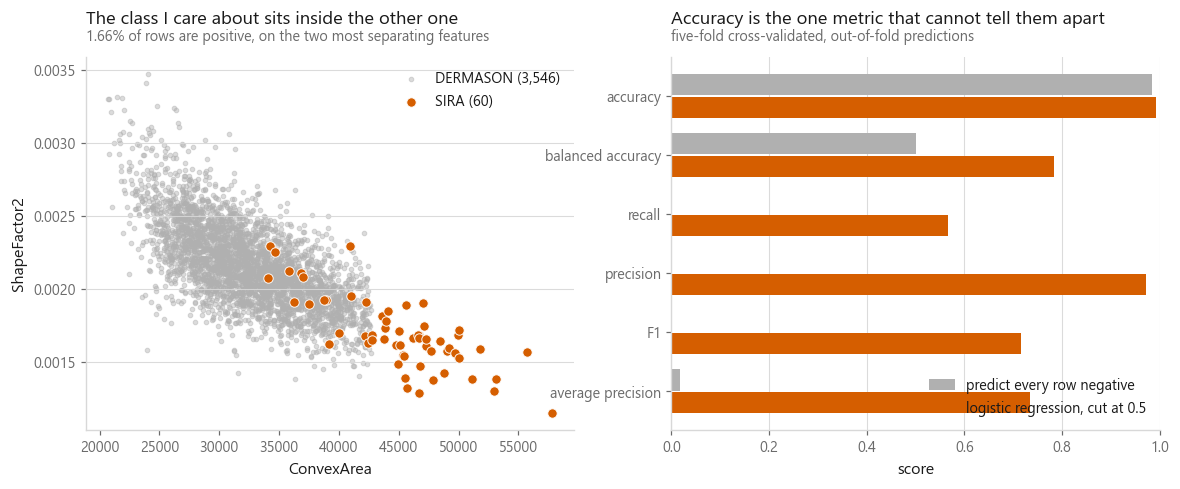

In [4]:
# Which two features show the problem best? Pick the one that separates the
# classes most, then the best one that is not a near-copy of it.
z = (X - X.mean(0)) / X.std(0)
gap = np.abs(z[y == 1].mean(0) - z[y == 0].mean(0))
first = int(np.argmax(gap))
corr = np.abs(np.corrcoef(z, rowvar=False)[first])
second = int(np.argmax(np.where(corr < 0.7, gap, -1.0)))
if second == first:
    second = int(np.argsort(gap)[-2])

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

axes[0].scatter(X[y == 0, first], X[y == 0, second], s=9, c=style.NEUTRAL,
                alpha=0.45, label=f"DERMASON ({int((1 - y).sum()):,})", zorder=0)
axes[0].scatter(X[y == 1, first], X[y == 1, second], s=38, c=style.HIGHLIGHT,
                marker=style.MARKERS[0], edgecolor="white", linewidth=0.6,
                label=f"SIRA ({int(y.sum())})", zorder=2)
axes[0].set_xlabel(FEATURES[first])
axes[0].set_ylabel(FEATURES[second])
axes[0].legend(loc="best")
style.title(axes[0], "The class I care about sits inside the other one",
            f"{BASE_RATE:.2%} of rows are positive, on the two most separating features")

pos = np.arange(len(METRICS))
axes[1].barh(pos - 0.19, baseline.iloc[0].to_numpy(), height=0.36,
             color=style.NEUTRAL, label="predict every row negative")
axes[1].barh(pos + 0.19, baseline.iloc[1].to_numpy(), height=0.36,
             color=style.HIGHLIGHT, label="logistic regression, cut at 0.5")
axes[1].set_yticks(pos, METRICS)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.0)
axes[1].set_xlabel("score")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
axes[1].legend(loc="lower right")
style.title(axes[1], "Accuracy is the one metric that cannot tell them apart",
            "five-fold cross-validated, out-of-fold predictions")

style.save(fig, FIG / "fig-01-accuracy-is-useless.png")

print(f"accuracy of predicting nothing : {baseline.iloc[0]['accuracy']:.4f}")
print(f"accuracy of the model          : {baseline.iloc[1]['accuracy']:.4f}")
print(f"difference                     : {baseline.iloc[1]['accuracy'] - baseline.iloc[0]['accuracy']:+.4f}")
print(f"recall of the model at 0.5     : {baseline.iloc[1]['recall']:.4f}")

Two rows of numbers, and the accuracy column separates them by almost nothing.
A model that has never once said "positive" is within a rounding error of a
real one, because accuracy is dominated by the class that makes up nearly all
the data.

Every other column tells the truth. Balanced accuracy averages recall on each
class instead of pooling rows, so the do-nothing model scores exactly one half
by construction. Precision, recall and F1 ignore true negatives entirely.

The metric I lean on for the rest of the notebook is **average precision**, the
area under the precision-recall curve. It summarises the ranking over every
threshold, so it answers "does this model put the rare rows near the top" without
committing to a cut. Its floor is the base rate, not one half, which is why the
do-nothing model scores near zero rather than looking respectable.

ROC-AUC is the more common choice and I avoid it here. With one positive per
few dozen rows, the false positive rate has an enormous denominator, so a model
can drown the reader in false alarms and still post an impressive ROC curve.

### The easy version of the same problem

In [5]:
# BOMBAY beans are much larger than DERMASON, so the rare class is trivial to find.
X_easy, y_easy = unbalanced("BOMBAY", 60)
oof_easy = cross_val_predict(logistic(), X_easy, y_easy, cv=single, method="predict_proba")[:, 1]

print(f"average precision, rare SIRA   : {average_precision_score(y, oof):.3f}")
print(f"average precision, rare BOMBAY : {average_precision_score(y_easy, oof_easy):.3f}")
print(f"recall at 0.5,     rare SIRA   : {recall_score(y, oof >= 0.5):.3f}")
print(f"recall at 0.5,     rare BOMBAY : {recall_score(y_easy, oof_easy >= 0.5):.3f}")

average precision, rare SIRA   : 0.735
average precision, rare BOMBAY : 1.000
recall at 0.5,     rare SIRA   : 0.567
recall at 0.5,     rare BOMBAY : 1.000


Same imbalance, same model, same number of positives, and the BOMBAY version is
close to solved before I do anything about the imbalance at all.

That is worth sitting with, because it means **imbalance on its own is not the
problem**. Rarity hurts when the rare class also overlaps the common one. If
your rare class is cleanly separable you can usually stop reading here, and if
it overlaps badly, no amount of resampling invents a separation that is not in
the features. I keep the hard SIRA version from now on.

## 3. The three families of fix

**Undersample the majority.** Throw away negatives until the classes match. It
is fast, it fixes the imbalance exactly, and it deletes most of your data.

**Oversample the minority.** Repeat the rare rows until the classes match.
Nothing is thrown away, but the copies carry no new information, and any model
flexible enough to memorise a row now sees that row many times.

SMOTE is the usual refinement: instead of copying a rare row, walk a random
fraction of the way from it toward one of its nearest rare neighbours and keep
the point you land on. The synthetic rows fill the gaps between real ones
rather than piling up on top of them. `imblearn` is not a dependency of this
book and the whole method is about ten lines of NumPy, so I write it out.

**Weight the loss.** Leave the data alone and tell the model that a rare row
counts for more. With $n$ rows, $k$ classes and $n_c$ rows in class $c$,
scikit-learn's `class_weight="balanced"` sets

$$w_c = \frac{n}{k \, n_c}$$

which makes the total weight of each class equal. It is what oversampling was
trying to achieve, done in the loss function instead of the data, with no
duplicated rows and no extra training time.

In [6]:
def as_is(X_part, y_part, rng):
    """The control: change nothing."""
    return X_part, y_part


def undersample(X_part, y_part, rng):
    positive = np.flatnonzero(y_part == 1)
    negative = np.flatnonzero(y_part == 0)
    keep = rng.choice(negative, size=len(positive), replace=False)
    idx = np.concatenate([positive, keep])
    return X_part[idx], y_part[idx]


def oversample(X_part, y_part, rng):
    positive = np.flatnonzero(y_part == 1)
    negative = np.flatnonzero(y_part == 0)
    extra = rng.choice(positive, size=len(negative) - len(positive), replace=True)
    idx = np.concatenate([negative, positive, extra])
    return X_part[idx], y_part[idx]


def smote(X_part, y_part, rng, k=5):
    """SMOTE by hand: new rare rows on the segments between existing rare rows."""
    positive = np.flatnonzero(y_part == 1)
    negative = np.flatnonzero(y_part == 0)
    P = X_part[positive]
    k = min(k, len(P) - 1)

    # neighbours are found on standardised features, otherwise Area alone
    # decides who is close to whom
    Z = (P - P.mean(0)) / np.clip(P.std(0), 1e-12, None)
    distance = np.linalg.norm(Z[:, None, :] - Z[None, :, :], axis=2)
    np.fill_diagonal(distance, np.inf)
    neighbours = np.argsort(distance, axis=1)[:, :k]

    n_new = len(negative) - len(P)
    source = rng.integers(0, len(P), n_new)
    mate = neighbours[source, rng.integers(0, k, n_new)]
    step = rng.random((n_new, 1))
    synthetic = P[source] + step * (P[mate] - P[source])

    X_new = np.vstack([X_part[negative], P, synthetic])
    y_new = np.concatenate([np.zeros(len(negative), dtype=int),
                            np.ones(len(P) + n_new, dtype=int)])
    return X_new, y_new


check_rng = np.random.default_rng(SEED)
for name, fn in [("as is", as_is), ("undersample", undersample),
                 ("oversample", oversample), ("SMOTE", smote)]:
    Xd, yd = fn(X, y, check_rng)
    distinct = len(np.unique(Xd[yd == 1], axis=0))
    print(f"{name:>12}: {len(yd):>5,} rows, {int(yd.sum()):>4} positive "
          f"({yd.mean():.1%}), {distinct:>4} distinct positive rows")

       as is: 3,606 rows,   60 positive (1.7%),   60 distinct positive rows
 undersample:   120 rows,   60 positive (50.0%),   60 distinct positive rows
  oversample: 7,092 rows, 3546 positive (50.0%),   60 distinct positive rows
       SMOTE: 7,092 rows, 3546 positive (50.0%), 3546 distinct positive rows


Look at the last column. Oversampling reports thousands of positive rows and a
few dozen distinct ones. SMOTE's rows are all distinct, but they are convex
combinations of that same few dozen, so the information content is closer to
the small number than the large one. Section 5 is where that bites.

### Scoring them on the same folds

Everything below runs through one function, so no method gets a quiet
advantage. The rule it enforces is the one that matters most in this notebook:
**the resampler only ever sees the training part of a fold.** The test part is
left at its natural, horrible base rate, because that is the rate you face in
production.

In [7]:
def best_f1_threshold(y_true, score):
    """The cut that maximises F1 on scores the model has not been fitted on."""
    precision, recall, cuts = precision_recall_curve(y_true, score)
    if len(cuts) == 0:
        return 0.5
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    return float(cuts[int(np.argmax(f1[:-1]))])


def _proba(model, resample, X_fit, y_fit, X_score, rng):
    X_r, y_r = resample(X_fit, y_fit, rng)
    return model().fit(X_r, y_r).predict_proba(X_score)[:, 1]


def cv_scores(X_data, y_data, folds, model, resample=as_is, threshold="half"):
    """One row per fold. `threshold` is 'half', 'base rate' or 'tuned'."""
    rows = []
    for k, (train, test) in enumerate(folds.split(X_data, y_data)):
        rng = np.random.default_rng(SEED + k)
        X_tr, y_tr, X_te, y_te = X_data[train], y_data[train], X_data[test], y_data[test]

        if threshold == "half":
            cut = 0.5
        elif threshold == "base rate":
            cut = float(y_tr.mean())          # training rows only, never y_te
        elif threshold == "tuned":
            inner = StratifiedKFold(3, shuffle=True, random_state=SEED)
            held = np.zeros(len(y_tr))
            for i_tr, i_te in inner.split(X_tr, y_tr):
                held[i_te] = _proba(model, resample, X_tr[i_tr], y_tr[i_tr], X_tr[i_te], rng)
            cut = best_f1_threshold(y_tr, held)
        else:
            raise ValueError(threshold)

        score = _proba(model, resample, X_tr, y_tr, X_te, rng)
        pred = (score >= cut).astype(int)
        rows.append({"f1": f1_score(y_te, pred, zero_division=0),
                     "precision": precision_score(y_te, pred, zero_division=0),
                     "recall": recall_score(y_te, pred, zero_division=0),
                     "average precision": average_precision_score(y_te, score),
                     "roc auc": roc_auc_score(y_te, score),
                     "balanced accuracy": balanced_accuracy_score(y_te, pred),
                     "threshold": cut})
    return pd.DataFrame(rows)


def compare(X_data, y_data, folds, recipes):
    per_fold = {name: cv_scores(X_data, y_data, folds, **cfg) for name, cfg in recipes.items()}
    table = pd.DataFrame({name: df.mean() for name, df in per_fold.items()}).T
    return per_fold, table


folds = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

families = {
    "plain @ 0.5": dict(model=lambda: logistic(), resample=as_is),
    "undersample @ 0.5": dict(model=lambda: logistic(), resample=undersample),
    "oversample @ 0.5": dict(model=lambda: logistic(), resample=oversample),
    "SMOTE @ 0.5": dict(model=lambda: logistic(), resample=smote),
    "weights @ 0.5": dict(model=lambda: logistic(class_weight="balanced"), resample=as_is),
}

family_folds, family_table = compare(X, y, folds, families)
print(family_table.drop(columns="threshold").round(3).to_string())

                      f1  precision  recall  average precision  roc auc  balanced accuracy
plain @ 0.5        0.712      0.963   0.577              0.748    0.963              0.788
undersample @ 0.5  0.205      0.117   0.873              0.496    0.963              0.878
oversample @ 0.5   0.227      0.130   0.873              0.624    0.967              0.887
SMOTE @ 0.5        0.231      0.134   0.850              0.627    0.966              0.878
weights @ 0.5      0.226      0.130   0.880              0.625    0.967              0.890


average precision, best minus worst : 0.2518
F1 at 0.5,        best minus worst : 0.5076


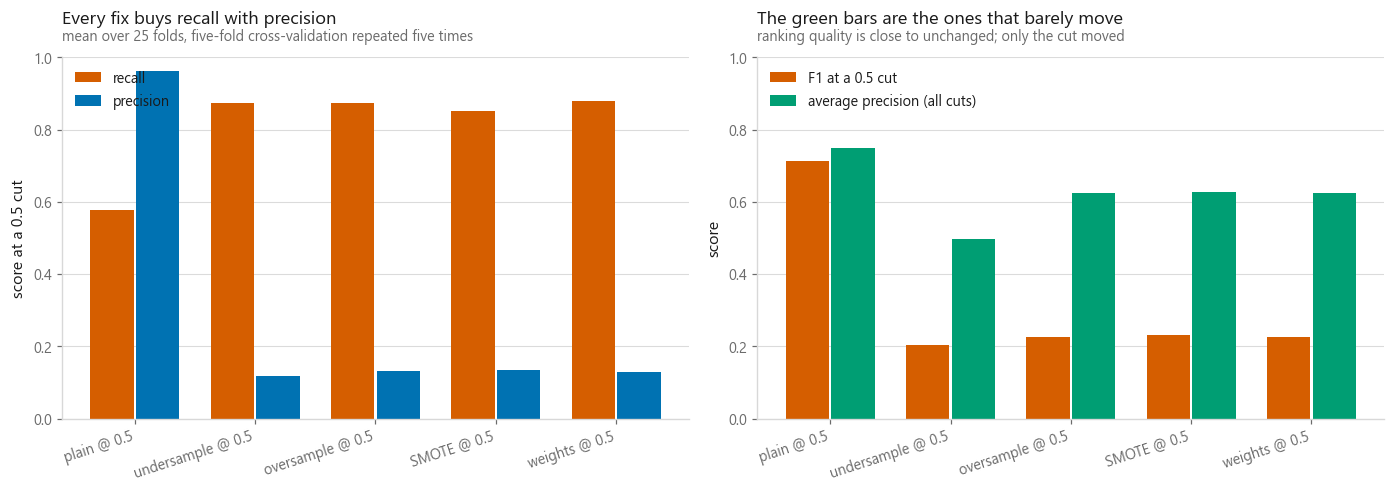

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
names = list(family_table.index)
pos = np.arange(len(names))

axes[0].bar(pos - 0.19, family_table["recall"], width=0.36,
            color=style.HIGHLIGHT, label="recall")
axes[0].bar(pos + 0.19, family_table["precision"], width=0.36,
            color=style.PALETTE[0], label="precision")
axes[0].set_xticks(pos, names, rotation=18, ha="right")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("score at a 0.5 cut")
axes[0].legend(loc="upper left")
style.title(axes[0], "Every fix buys recall with precision",
            "mean over 25 folds, five-fold cross-validation repeated five times")

axes[1].bar(pos - 0.19, family_table["f1"], width=0.36,
            color=style.HIGHLIGHT, label="F1 at a 0.5 cut")
axes[1].bar(pos + 0.19, family_table["average precision"], width=0.36,
            color=style.PALETTE[2], label="average precision (all cuts)")
axes[1].set_xticks(pos, names, rotation=18, ha="right")
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("score")
axes[1].legend(loc="upper left")
style.title(axes[1], "The green bars are the ones that barely move",
            "ranking quality is close to unchanged; only the cut moved")

fig.tight_layout()
style.save(fig, FIG / "fig-02-three-families.png")

spread = family_table["average precision"]
print(f"average precision, best minus worst : {spread.max() - spread.min():.4f}")
print(f"F1 at 0.5,        best minus worst : "
      f"{family_table['f1'].max() - family_table['f1'].min():.4f}")

The left panel is the mechanism in one picture. Every fix pushes recall up and
pulls precision down, which is what you would expect from a decision boundary
that has been shoved toward the majority class.

The right panel is the part that made me write this notebook. F1 at a fixed cut
of 0.5 moves around a lot between methods. Average precision, which reads the
whole ranking rather than one cut, moves far less. Undersampling is usually the
exception and for an obvious reason: it is the only one that deletes real rows,
so it is the only one that can genuinely damage the ranking.

If the ranking is nearly the same and only the cut differs, then resampling is
an expensive way of moving a threshold. The next section tests that directly.

## 4. Threshold moving, compared fairly

Here is why a cut at 0.5 and a rebalanced training set are the same idea.

Suppose the model is calibrated on the original data, so it reports
$p(x) = P(y = 1 \mid x)$. Now duplicate the rare rows until both classes are the
same size and refit. The features did not change and the class-conditional
densities did not change. Only the prior did, from $\pi$ to $\pi'$. Bayes' rule
turns a change of prior into a multiplication of the odds:

$$\frac{p'(x)}{1 - p'(x)} = r \cdot \frac{p(x)}{1 - p(x)},
  \qquad r = \frac{\pi' / (1 - \pi')}{\pi / (1 - \pi)}$$

Cutting the new score at one half means setting the new odds to 1, so the old
odds must equal $1/r$, so the decision is

$$p(x) \; \ge \; \frac{1}{1 + r}$$

Rebalancing all the way to fifty-fifty makes $\pi' = 1/2$, so
$r = (1 - \pi) / \pi = n_{\text{neg}} / n_{\text{pos}}$, and

$$\frac{1}{1 + r} = \frac{n_{\text{pos}}}{n_{\text{pos}} + n_{\text{neg}}} = \pi$$

**Rebalance the training set and cut at 0.5, and you have cut the original
model at the base rate.** That is the whole trick, and you can have it for one
line of arithmetic instead of a resampler.

So I add two more entries to the comparison. One cuts the plain model at the
training-fold base rate, with no tuning of any kind. The other tunes the cut
for F1 on an inner three-fold split of the training part, so the test fold
never touches the choice.

In [9]:
recipes = dict(families)
recipes["plain @ base rate"] = dict(model=lambda: logistic(), resample=as_is,
                                    threshold="base rate")
recipes["plain @ tuned"] = dict(model=lambda: logistic(), resample=as_is,
                                threshold="tuned")

all_folds, table = compare(X, y, folds, recipes)
print(table.round(3).to_string())
print()
tuned = all_folds["plain @ tuned"]["threshold"]
print(f"tuned cut across folds : mean {tuned.mean():.4f}, "
      f"sd {tuned.std():.4f}, range {tuned.min():.4f} to {tuned.max():.4f}")
print(f"the base rate itself   : {BASE_RATE:.4f}")

                      f1  precision  recall  average precision  roc auc  balanced accuracy  threshold
plain @ 0.5        0.712      0.963   0.577              0.748    0.963              0.788      0.500
undersample @ 0.5  0.205      0.117   0.873              0.496    0.963              0.878      0.500
oversample @ 0.5   0.227      0.130   0.873              0.624    0.967              0.887      0.500
SMOTE @ 0.5        0.231      0.134   0.850              0.627    0.966              0.878      0.500
weights @ 0.5      0.226      0.130   0.880              0.625    0.967              0.890      0.500
plain @ base rate  0.225      0.130   0.850              0.748    0.963              0.877      0.017
plain @ tuned      0.723      0.917   0.610              0.748    0.963              0.805      0.338

tuned cut across folds : mean 0.3381, sd 0.0630, range 0.2616 to 0.5569
the base rate itself   : 0.0166


best resampler F1      : 0.2313
plain @ base rate F1   : 0.2252
plain @ tuned F1       : 0.7227


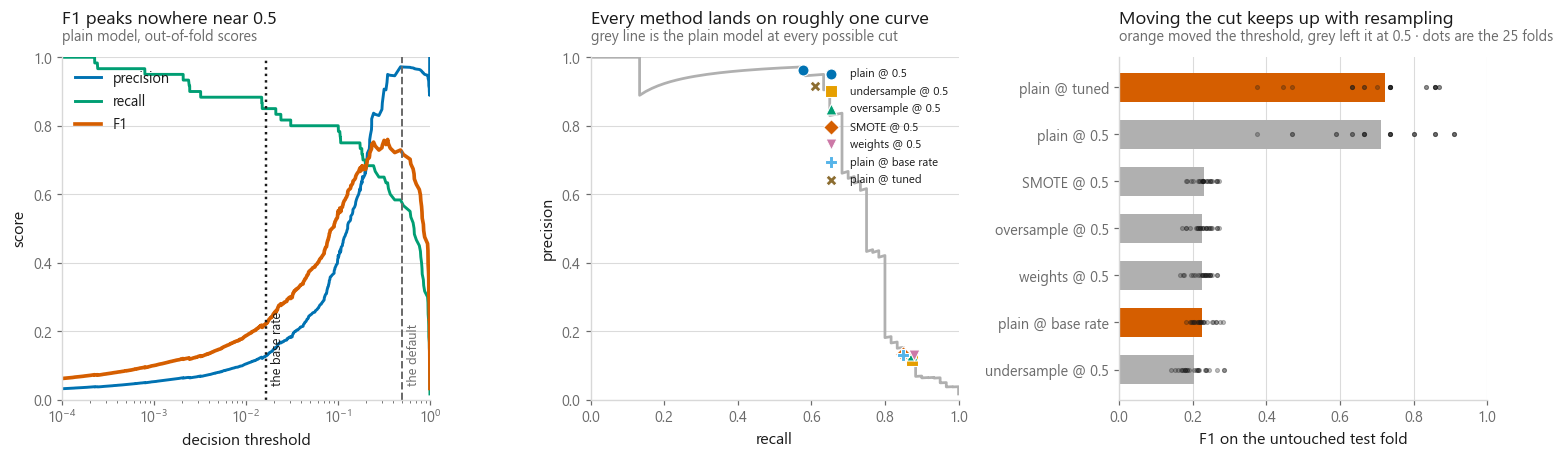

In [10]:
precision_curve, recall_curve, cuts = precision_recall_curve(y, oof)
f1_curve = 2 * precision_curve * recall_curve / np.clip(precision_curve + recall_curve, 1e-12, None)

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.3))

axes[0].plot(cuts, precision_curve[:-1], color=style.PALETTE[0], label="precision")
axes[0].plot(cuts, recall_curve[:-1], color=style.PALETTE[2], label="recall")
axes[0].plot(cuts, f1_curve[:-1], color=style.HIGHLIGHT, lw=2.4, label="F1")
axes[0].axvline(0.5, color=style.MUTED, ls="--", lw=1.3)
axes[0].axvline(BASE_RATE, color=style.INK, ls=":", lw=1.6)
axes[0].annotate("the default", xy=(0.5, 0.04), xytext=(3, 0), textcoords="offset points",
                 fontsize=8.5, color=style.MUTED, rotation=90, va="bottom")
axes[0].annotate("the base rate", xy=(BASE_RATE, 0.04), xytext=(3, 0),
                 textcoords="offset points", fontsize=8.5, color=style.INK,
                 rotation=90, va="bottom")
axes[0].set_xscale("log")
axes[0].set_xlim(1e-4, 1.0)
axes[0].set_ylim(0, 1.0)
axes[0].set_xlabel("decision threshold")
axes[0].set_ylabel("score")
axes[0].legend(loc="upper left")
style.title(axes[0], "F1 peaks nowhere near 0.5", "plain model, out-of-fold scores")

axes[1].plot(recall_curve, precision_curve, color=style.NEUTRAL, lw=1.8)
for i, name in enumerate(table.index):
    axes[1].scatter(table.loc[name, "recall"], table.loc[name, "precision"],
                    s=52, marker=style.MARKERS[i % len(style.MARKERS)],
                    color=style.PALETTE[i % len(style.PALETTE)],
                    edgecolor="white", linewidth=0.7, zorder=3, label=name)
axes[1].set_xlim(0, 1.0)
axes[1].set_ylim(0, 1.0)
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].legend(fontsize=7.5, loc="upper right")
style.title(axes[1], "Every method lands on roughly one curve",
            "grey line is the plain model at every possible cut")

order = table["f1"].sort_values().index
bar_pos = np.arange(len(order))
colours = [style.HIGHLIGHT if "@ 0.5" not in n else style.NEUTRAL for n in order]
axes[2].barh(bar_pos, table.loc[order, "f1"], color=colours, height=0.62)
for i, name in enumerate(order):
    axes[2].scatter(all_folds[name]["f1"], np.full(len(all_folds[name]), i),
                    s=7, color=style.INK, alpha=0.28, zorder=3)
axes[2].set_yticks(bar_pos, order)
axes[2].set_xlim(0, 1.0)
axes[2].set_xlabel("F1 on the untouched test fold")
axes[2].grid(axis="y", visible=False)
axes[2].grid(axis="x", visible=True)
style.title(axes[2], "Moving the cut keeps up with resampling",
            "orange moved the threshold, grey left it at 0.5 · dots are the 25 folds")

fig.tight_layout()
style.save(fig, FIG / "fig-03-threshold-moving.png")

best_resampler = table.loc[["undersample @ 0.5", "oversample @ 0.5", "SMOTE @ 0.5"], "f1"].max()
print(f"best resampler F1      : {best_resampler:.4f}")
print(f"plain @ base rate F1   : {table.loc['plain @ base rate', 'f1']:.4f}")
print(f"plain @ tuned F1       : {table.loc['plain @ tuned', 'f1']:.4f}")

The middle panel is the argument. Every method is a dot on a curve that belongs
to the plain model, and they differ in where they sit along it far more than in
how far above it they get. Resampling moved you down the curve toward recall.
You can move down that curve by typing a smaller number.

The right panel is the same result as a ranking, with the twenty-five fold
scores drawn as dots so you can see how much the ordering is worth. The spread
within one method overlaps the gaps between methods, which is the usual state
of affairs on a problem with a few dozen positives, and a good reason not to
make too much of small differences.

Two practical notes. The tuned cut varies quite a bit fold to fold, because it
is chosen from a handful of positives; the base-rate cut needs no data at all
and is not far off. And a threshold is a dial, which is what people actually
want. "Catch ninety percent of the fraud" is a request you can satisfy exactly
by reading a threshold off the recall curve. There is no resampling ratio that
takes that request as input.

### The same test on a second dataset

Breast Cancer, with the malignant rows thinned out until they are rare. It is a
few hundred rows, so I repeat the cross-validation more times to keep the noise
down.

In [11]:
X_bc_all, y_bc_all = datasets.breast_cancer()
bc_rng = np.random.default_rng(SEED)

benign = np.flatnonzero(y_bc_all.to_numpy() == 1)          # 1 is benign, 0 is malignant
malignant = np.flatnonzero(y_bc_all.to_numpy() == 0)
keep_bc = np.sort(np.concatenate([benign, bc_rng.choice(malignant, size=18, replace=False)]))

X_bc = X_bc_all.to_numpy(dtype=float)[keep_bc]
y_bc = (y_bc_all.to_numpy()[keep_bc] == 0).astype(int)     # positive = malignant

bc_folds = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
_, bc_table = compare(X_bc, y_bc, bc_folds, recipes)

print(f"{len(y_bc)} rows, {int(y_bc.sum())} positive ({y_bc.mean():.2%})\n")
print(bc_table[["f1", "precision", "recall", "average precision"]].round(3).to_string())

375 rows, 18 positive (4.80%)

                      f1  precision  recall  average precision
plain @ 0.5        0.928      1.000   0.883              0.993
undersample @ 0.5  0.726      0.610   0.980              0.900
oversample @ 0.5   0.937      0.935   0.955              0.997
SMOTE @ 0.5        0.932      0.930   0.950              0.997
weights @ 0.5      0.945      0.963   0.940              0.994
plain @ base rate  0.823      0.720   0.995              0.993
plain @ tuned      0.914      0.960   0.898              0.993


A different dataset, a different base rate, an easier separation, and the shape
of the answer holds: the resamplers and the moved thresholds finish close
together, and the ranking metric hardly cares which one you used.

## 5. Leakage: resampling before the split

This is the mistake that produces the impressive numbers you see in tutorials.
It looks harmless:

```python
X_res, y_res = some_resampler(X, y)      # the whole dataset
cross_val_score(model, X_res, y_res)     # now split it
```

Oversampling made copies of rare rows. Splitting afterwards deals those copies
into both halves, so the model is scored on rows it was fitted on. SMOTE is the
same story one step removed: a synthetic test row is built by interpolating two
training rows, so the answer is sitting in the training set even though no row
is repeated exactly.

Undersampling does not duplicate anything, and it leaks differently. It throws
away negatives before the split, so the test fold ends up balanced. Precision
measured on a balanced test set is not the precision you will get at the real
base rate — it is much better, and it is fiction.

I run both orders, on a linear model and on a random forest, because the size
of the damage depends on how much the model is able to memorise.

In [12]:
from sklearn.ensemble import RandomForestClassifier


def forest():
    return RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)


def leaky_f1(model, resample, X_data, y_data):
    """The mistake: resample everything, then cross-validate the result."""
    rng = np.random.default_rng(SEED)
    X_r, y_r = resample(X_data, y_data, rng)
    scores = []
    for train, test in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_r, y_r):
        pred = model().fit(X_r[train], y_r[train]).predict(X_r[test])
        scores.append(f1_score(y_r[test], pred, zero_division=0))
    return float(np.mean(scores))


resamplers = {"undersample": undersample, "oversample": oversample, "SMOTE": smote}
models = {"logistic regression": lambda: logistic(), "random forest": forest}

leak = []
for model_name, model in models.items():
    for res_name, resample in resamplers.items():
        wrong = leaky_f1(model, resample, X, y)
        right = cv_scores(X, y, single, model, resample=resample).mean()["f1"]
        leak.append({"model": model_name, "resampler": res_name,
                     "before the split": wrong, "inside the fold": right,
                     "inflation": wrong - right})

leak = pd.DataFrame(leak)
print(leak.round(3).to_string(index=False))

              model   resampler  before the split  inside the fold  inflation
logistic regression undersample             0.882            0.202      0.680
logistic regression  oversample             0.910            0.229      0.681
logistic regression       SMOTE             0.908            0.237      0.672
      random forest undersample             0.838            0.251      0.586
      random forest  oversample             1.000            0.786      0.213
      random forest       SMOTE             0.991            0.640      0.351


In [13]:
# How much of the test fold did the model already see?
dup_rng = np.random.default_rng(SEED)
X_over, y_over = oversample(X, y, dup_rng)
_, row_id = np.unique(X_over, axis=0, return_inverse=True)
row_id = np.ravel(row_id)
train, test = next(iter(StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_over, y_over)))
test_positive = test[y_over[test] == 1]
seen = np.isin(row_id[test_positive], row_id[train])

X_under, y_under = undersample(X, y, np.random.default_rng(SEED))

print(f"{seen.mean():.1%} of the positive test rows are exact copies of a training row")
print(f"positive rate in an honest test fold      : {BASE_RATE:.2%}")
print(f"positive rate after undersampling first   : {y_under.mean():.2%}")

100.0% of the positive test rows are exact copies of a training row
positive rate in an honest test fold      : 1.66%
positive rate after undersampling first   : 50.00%


largest inflation: oversample with logistic regression, 0.910 reported against 0.229 real (+0.681)


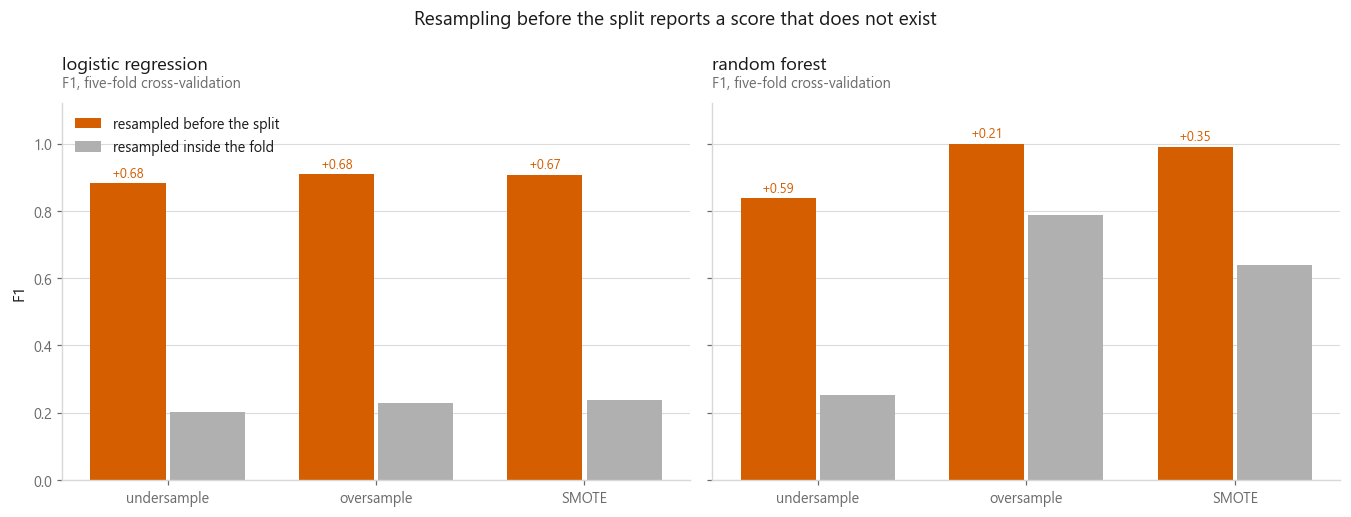

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), sharey=True)

for ax, (model_name, block) in zip(axes, leak.groupby("model", sort=False)):
    pos = np.arange(len(block))
    ax.bar(pos - 0.19, block["before the split"], width=0.36,
           color=style.HIGHLIGHT, label="resampled before the split")
    ax.bar(pos + 0.19, block["inside the fold"], width=0.36,
           color=style.NEUTRAL, label="resampled inside the fold")
    for i, (wrong, right) in enumerate(zip(block["before the split"], block["inside the fold"])):
        ax.annotate(f"+{wrong - right:.2f}", xy=(i - 0.19, wrong), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=8.5,
                    color=style.HIGHLIGHT)
    ax.set_xticks(pos, block["resampler"])
    ax.set_ylim(0, 1.12)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)
    style.title(ax, model_name, "F1, five-fold cross-validation")

axes[0].set_ylabel("F1")
axes[0].legend(loc="upper left")
fig.tight_layout()
fig.suptitle("Resampling before the split reports a score that does not exist",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-leakage.png")

worst = leak.loc[leak["inflation"].idxmax()]
print(f"largest inflation: {worst['resampler']} with {worst['model']}, "
      f"{worst['before the split']:.3f} reported against {worst['inside the fold']:.3f} real "
      f"({worst['inflation']:+.3f})")

The gap is the score you would have claimed and never delivered. It is much
larger for the forest than for the linear model, and that is the point: a
linear model cannot memorise a duplicated row very well, while a tree can put
it in its own leaf. The more flexible your model, the more the leak pays out.

Undersampling inflates for a different reason and it inflates anyway. Nothing
is duplicated, but the test fold is now half positive instead of a fraction of
a percent, so precision is measured in a world that does not exist.

The fix is mechanical. Resampling is a step of the model, so it belongs inside
the pipeline that gets fitted on the training fold, never in the cell where
you load the data. Class weights and thresholds cannot make this mistake,
because they never create a row.

## Cheat sheet

| | |
|---|---|
| **First thing to do** | Stop reading accuracy. Use average precision, or precision and recall at a stated cut. ROC-AUC flatters a rare-class model |
| **Second thing to do** | Move the threshold. Start at the base rate, tune it on held-out folds if you have positives to spare |
| **Class weights** | `class_weight="balanced"` is oversampling done in the loss. No duplicated rows, no extra training time, cannot leak |
| **Random oversampling** | Safe on the ranking, dangerous in a pipeline. Every duplicate is a chance to leak |
| **SMOTE** | Interpolates instead of copying. Needs scaled features to pick neighbours, and still leaks if you run it before splitting |
| **Undersampling** | The only fix that deletes real information. Worth it when the majority class is enormous and training time is the constraint |
| **Always** | Resample inside the fold. The test fold keeps its natural base rate, always |
| **Remember** | If the classes overlap badly, none of this creates a separation. If they do not overlap, you did not need any of it |
| **Next** | [Probability calibration](../09-probability-calibration/), which is what makes a chosen threshold mean the same thing tomorrow |

## What to remember

1. Accuracy on a rare-class problem is a measurement of the common class. A
   model that never predicts positive will look almost as good as a real one.
2. Resampling and class weights mostly move where the decision is cut. They
   change the ranking much less than the headline F1 suggests.
3. Training on a fully rebalanced set and cutting at 0.5 is, for a calibrated
   model, the same decision as cutting the original model at the base rate.
4. A threshold is a dial you can set to the recall your problem requires. No
   resampling ratio accepts that as an input.
5. Resample inside the cross-validation fold. Doing it first duplicates rows
   across the split, and the more flexible the model the more score it invents.
6. Imbalance alone is not the difficulty. Imbalance plus overlap is.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-08 Multiclass and multilabel](../08-multiclass-and-multilabel/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#ImbalancedData` `#SMOTE` `#ClassWeights` `#Threshold`
`#PrecisionRecall` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`